# 1 - Ejercicios Matplotlib

Importar CSV - Chicago_Crimes_2017.csv

In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("ewanwallace/chicagocrimes2017")
csv_path = os.path.join(path, "Crimes-2017.csv")

data = pd.read_csv(csv_path)
data.head()

Using Colab cache for faster access to the 'chicagocrimes2017' dataset.


,G,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,11227287,JB147188,10/08/2017 03:00,092XX S RACINE AVE,281,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,RESIDENCE,False,False,...,21,73,2,NaN,NaN,2017,02/11/2018 15:57,NaN,NaN,NaN
1,11227583,JB147595,03/28/2017 02:00:00 PM,026XX W 79TH ST,620,BURGLARY,UNLAWFUL ENTRY,OTHER,False,False,...,18,70,5,NaN,NaN,2017,02/11/2018 15:57,NaN,NaN,NaN
2,11227293,JB147230,09/09/2017 20:17,060XX S EBERHART AVE,810,THEFT,OVER $500,RESIDENCE,False,False,...,20,42,6,NaN,NaN,2017,02/11/2018 15:57,NaN,NaN,NaN
3,11227634,JB147599,08/26/2017 10:00:00 AM,001XX W RANDOLPH ST,281,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,HOTEL/MOTEL,False,False,...,42,32,2,NaN,NaN,2017,02/11/2018 15:57,NaN,NaN,NaN
4,11227508,JB146365,01/01/2017 00:01,027XX S WHIPPLE ST,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,RESIDENCE,False,False,...,12,30,2,NaN,NaN,2017,02/11/2018 15:57,NaN,NaN,NaN


## Ejercicio 1

Genera un gráfico de barras que contenga el nº de siniestros ocurrido en cada mes del año. El gráfico será tal que así:

['G', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']


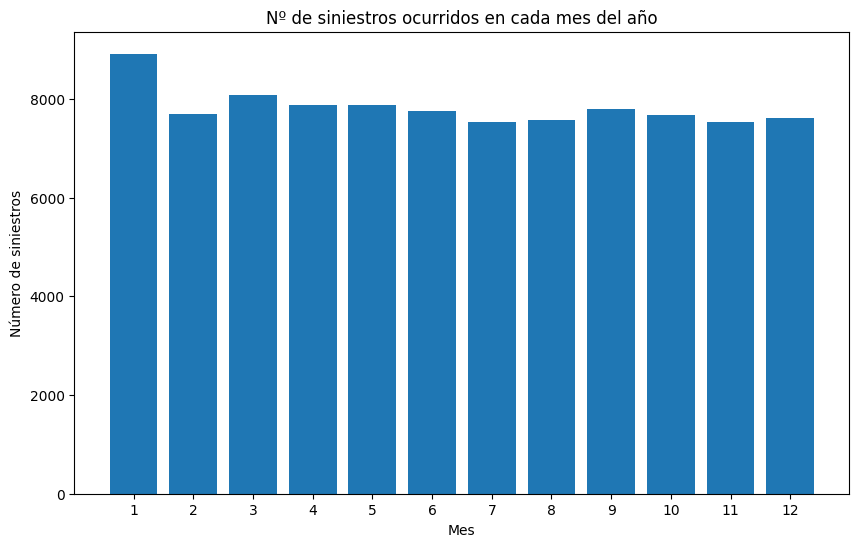

In [ ]:
print(data.columns.tolist())

columna_fecha = 'Date'

data.columns = data.columns.str.strip()
data[columna_fecha] = pd.to_datetime(data[columna_fecha], dayfirst=True, errors='coerce')
data['Mes'] = data[columna_fecha].dt.month
data = data.dropna(subset=['Mes'])
num_by_month = data.groupby('Mes').size()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(num_by_month.index, num_by_month.values)
ax.set_xlabel('Mes')
ax.set_ylabel('Número de siniestros')
ax.set_title('Nº de siniestros ocurridos en cada mes del año')
plt.xticks(range(1, 13))
plt.show()

## Ejercicio 2

Añade al gráfico anterior, usando puntos, el nº de siniestros cuyo Primary Type = 'Battery'.
- Representa esos puntos usando el eje derecho.
- Muestra una leyenda con el significado de ambos

El gráfico sería algo tal que así:

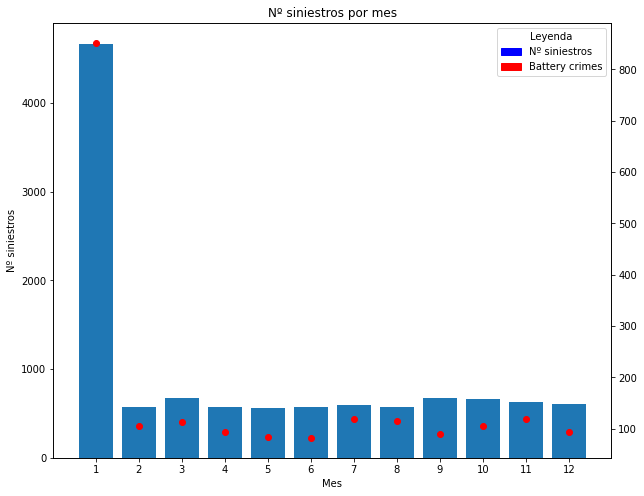

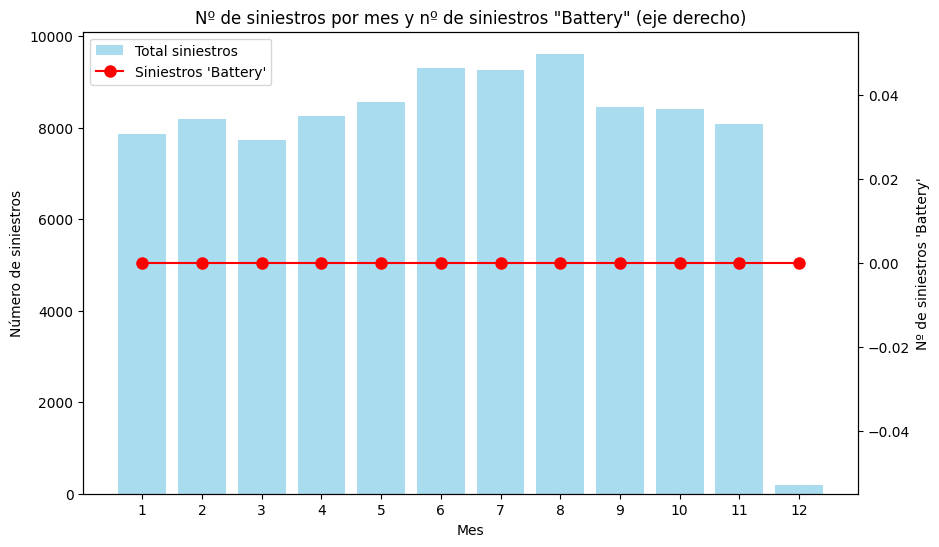

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar y preparar los datos
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True, errors='coerce')
data['Mes'] = data['Date'].dt.day
data['Mes_corr'] = data['Mes'].apply(lambda x: 1 if x > 12 else x)

# Conteo total de siniestros por mes
total_siniestros = data.groupby('Mes_corr').size()

# Conteo de siniestros con Primary Type = 'Battery'
battery_siniestros = data[data['Primary Type'] == 'Battery'].groupby('Mes_corr').size()

# Prepara los meses 1-12 aunque algún mes falte (rellena con 0 si falta)
meses = range(1, 13)
total_por_mes = [total_siniestros.get(m, 0) for m in meses]
battery_por_mes = [battery_siniestros.get(m, 0) for m in meses]

# Crear el gráfico combinado
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfico de barras izquierdo: total siniestros
ax1.bar(meses, total_por_mes, color='skyblue', label='Total siniestros', alpha=0.7)
ax1.set_xlabel('Mes')
ax1.set_ylabel('Número de siniestros')
ax1.set_xticks(meses)

# Eje derecho para 'Battery'
ax2 = ax1.twinx()
ax2.plot(meses, battery_por_mes, 'o-', color='red', label="Siniestros 'Battery'", markersize=8)
ax2.set_ylabel("Nº de siniestros 'Battery'")

# Leyenda
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Nº de siniestros por mes y nº de siniestros "Battery" (eje derecho)')
plt.show()


## Ejercicio 3

Filtra solo los siniestros cuyo Primary Type son "THEFT", "BATTERY", "CRIMINAL DAMAGE" o "OTHER OFFENSE". Luego, genera 2 gráficos en el mismo fig.

- El primero, será un gráfico de tartas que muestre el % que representa cada tipo en el dataset.
- El segundo, será un gráfico de puntos, representando el nº de siniestros de cada tipo en cada mes.

El resultado final, sería algo tal que así:

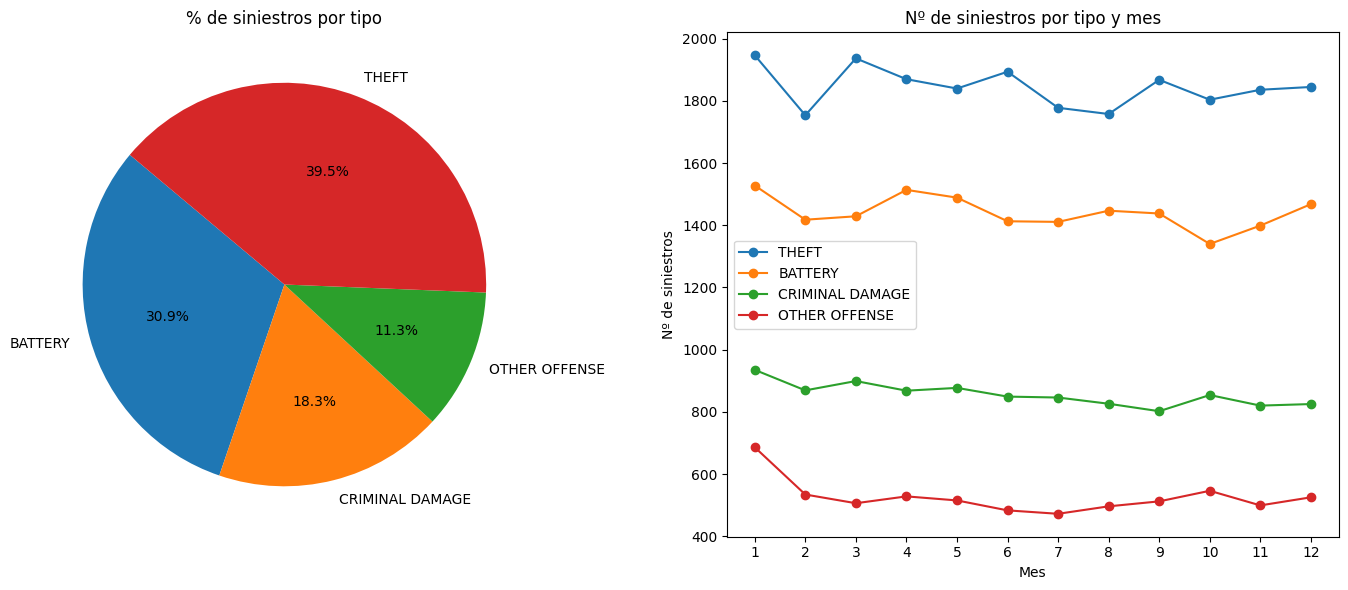

In [14]:
import matplotlib.pyplot as plt

# Filtrar los 4 tipos
tipos = ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'OTHER OFFENSE']
data_filtrado = data[data['Primary Type'].isin(tipos)].copy()

# Aseguramos columna Mes
data_filtrado['Date'] = pd.to_datetime(data_filtrado['Date'], errors='coerce')
data_filtrado['Mes'] = data_filtrado['Date'].dt.month
data_filtrado = data_filtrado.dropna(subset=['Mes'])
data_filtrado['Mes'] = data_filtrado['Mes'].astype(int)

# Conteo por tipo
conteo_tipo = data_filtrado.groupby('Primary Type').size()

# Conteo por tipo y mes
conteo_tipo_mes = data_filtrado.groupby(['Mes', 'Primary Type']).size().unstack(fill_value=0)

# Figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: Tarta
ax1.pie(conteo_tipo.values, labels=conteo_tipo.index, autopct='%1.1f%%', startangle=140)
ax1.set_title('% de siniestros por tipo')

# Grafico 2: Puntos (scatter) por mes y tipo
for tipo in tipos:
    if tipo in conteo_tipo_mes.columns:
        ax2.plot(conteo_tipo_mes.index, conteo_tipo_mes[tipo], marker='o', label=tipo)

ax2.set_xlabel('Mes')
ax2.set_ylabel('Nº de siniestros')
ax2.set_title('Nº de siniestros por tipo y mes')
ax2.set_xticks(range(1, 13))
ax2.legend()

plt.tight_layout()
plt.show()

# 2 - Ejercicios Seaborn

En este notebook de ejercicios vais a trabajar con el dataset 'penguins', el cual posee características de distintos pingüinos.

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
data = sns.load_dataset('penguins')
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Ejercicio 1

Genera un gráfico de regresión usando las variables 'bill_length_mm' y 'flipper_length_mm'. Implementa este gráfico separado por la variable 'sex'.

- Implementa el gráfico sin separar por sexo, podemos usar 'regplot'.

- Implementa el gráfico separando por sexo, usa el gráfico ***lmplot***

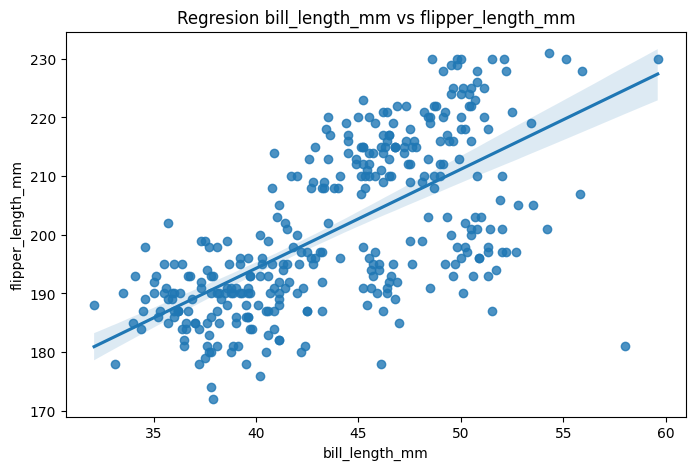

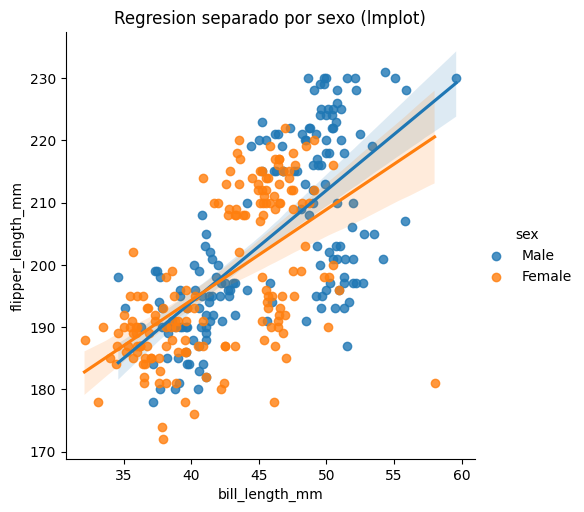

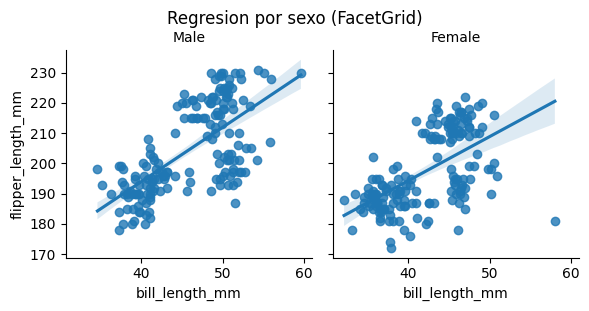

In [16]:
# Ejercicio 1 - Graficos de regresion

# 1a) regplot sin separar por sexo
plt.figure(figsize=(8, 5))
sns.regplot(data=data, x='bill_length_mm', y='flipper_length_mm')
plt.title('Regresion bill_length_mm vs flipper_length_mm')
plt.show()

# 1b) lmplot separando por sexo
sns.lmplot(data=data, x='bill_length_mm', y='flipper_length_mm', hue='sex')
plt.title('Regresion separado por sexo (lmplot)')
plt.show()

# 1c) FacetGrid separando por sexo
g = sns.FacetGrid(data, col='sex')
g.map_dataframe(sns.regplot, x='bill_length_mm', y='flipper_length_mm')
g.set_titles(col_template='{col_name}')
g.set_axis_labels('bill_length_mm', 'flipper_length_mm')
plt.suptitle('Regresion por sexo (FacetGrid)', y=1.02)
plt.show()

- Implementa el gráfico separando por sexos usando 'FacetGrid'

## Ejercicio 2

¿Existe algún valor anómalo (outlier) en alguna variable? Puedes usar gráficos BoxPlot para averiguarlos

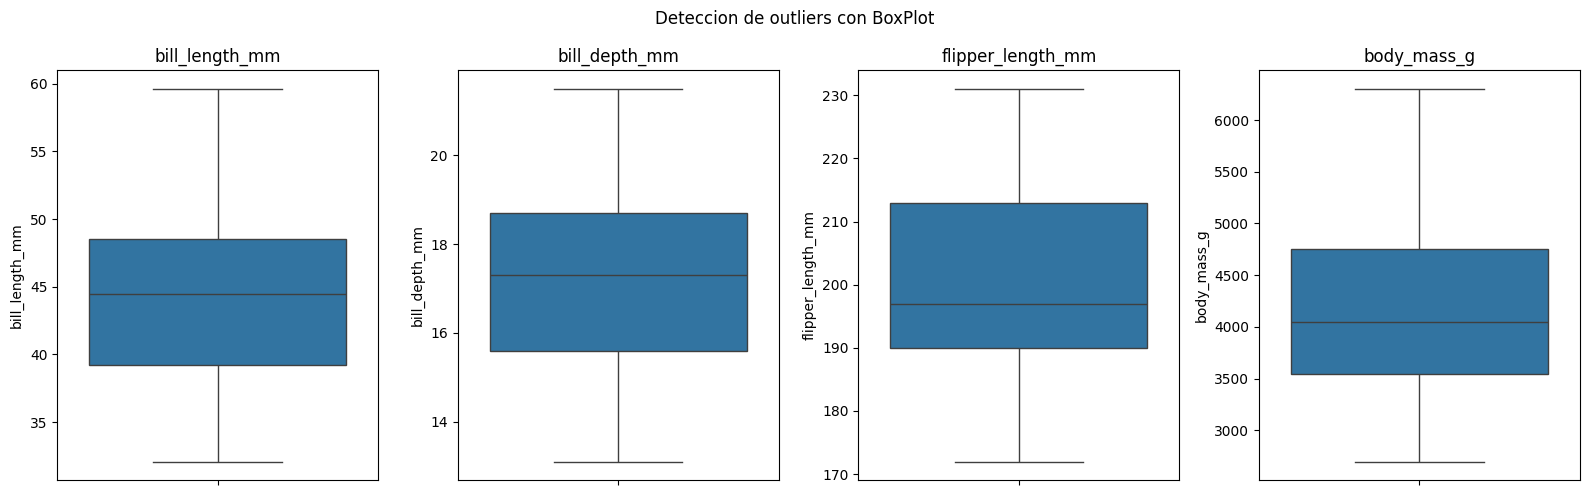

In [17]:
# Ejercicio 2 - Outliers con BoxPlot
numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(1, len(numericas), figsize=(16, 5))

for i, col in enumerate(numericas):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(col)

plt.suptitle('Deteccion de outliers con BoxPlot')
plt.tight_layout()
plt.show()

## Ejercicio 3

Genera un gráfico que contenga todas las combinaciones de variables. Dicho gráfico debe contener:
- Un histograma en la diagonal
- Un gráfico de puntos encima de la diagonal
- Un gráfico de distribución debajo de la diagonal


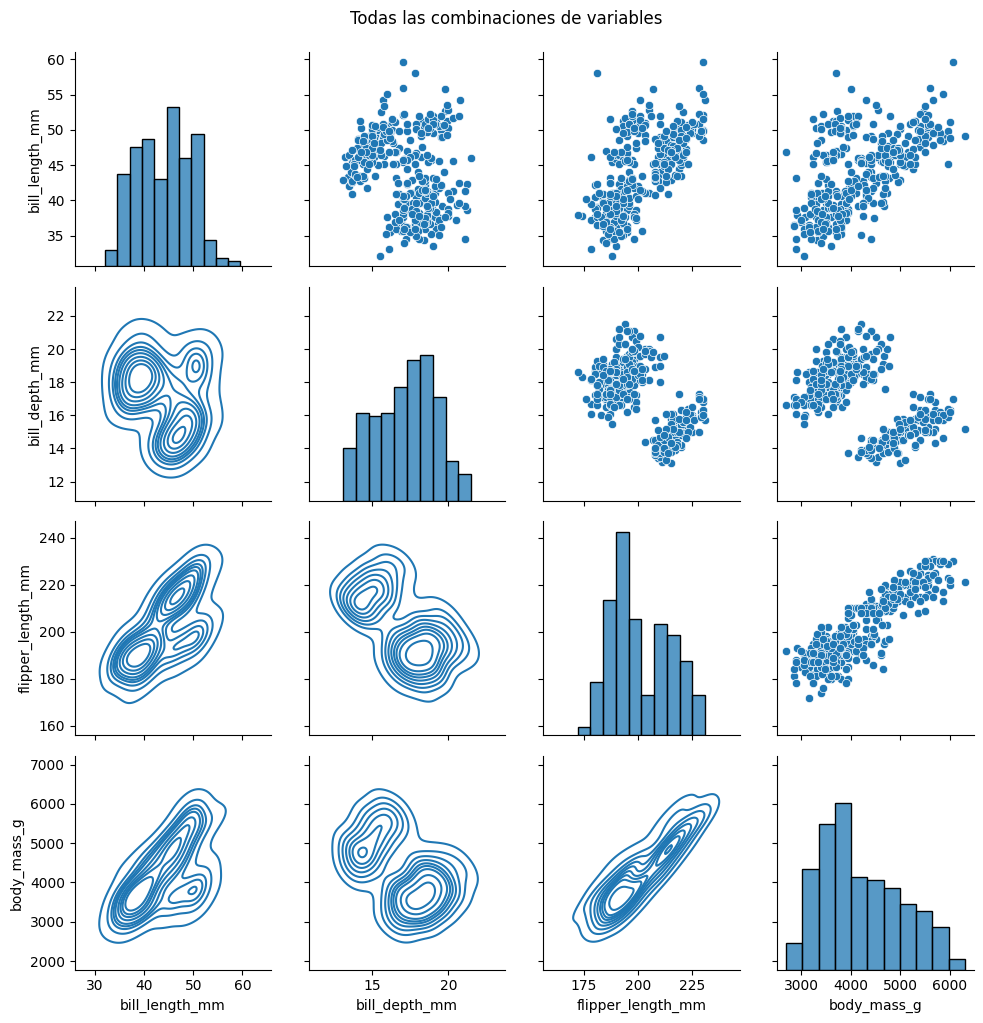

In [18]:
# Ejercicio 3 - Todas las combinaciones de variables (PairGrid)
# - Diagonal: histograma
# - Encima de la diagonal: grafico de puntos (scatter)
# - Debajo de la diagonal: grafico de distribucion (kdeplot)

g = sns.PairGrid(data.dropna(), vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'])

# Diagonal: histograma
g.map_diag(sns.histplot)

# Encima de la diagonal: scatter
g.map_upper(sns.scatterplot)

# Debajo de la diagonal: kdeplot (distribucion)
g.map_lower(sns.kdeplot)

plt.suptitle('Todas las combinaciones de variables', y=1.02)
plt.show()